# Simulating an acquisition

Every `test_tiffs/` fixture used across `../analyses/` was generated the same way this
notebook demonstrates: `pyS3M.simulation.pattern_source.simulate_acquisition` renders a
synthetic Bayer-mosaic camera stack from a pattern image, with a known injected ground
truth — the same backend `claude/generate_test_fixtures.py` uses internally, exposed here
as a plain, reusable function.

The workflow: load a pattern image → assign a dye to each detected colour → simulate →
write to disk as a real, fittable TIFF stack → round-trip it through the exact same
`AnalysisPipeline.fit` pipeline `01_getting_started_smlm_fitting.ipynb` used, to see
recovered positions against the injected ground truth.

INFO:pyS3M.AnalysisPipeline:AnalysisPipeline initialised (camera=ximea, pixel_size=0.0690 µm)


INFO:pyS3M.AnalysisPipeline:Calibration loaded from /home/jbeckwith/Documents/Chemistry/Lee/Code/Python/pyS3M/Camera_Calibrations/Ximea_Camera


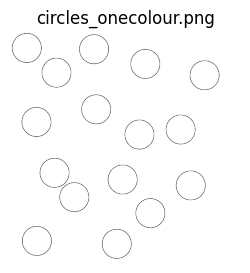

In [1]:
from pathlib import Path
import tempfile
import json
import numpy as np
import matplotlib.pyplot as plt

from pyS3M.AnalysisPipeline import AnalysisPipeline, FittingConfig
from pyS3M.Constants import AnalysisConfig
from pyS3M.clustering import ClusteringConfig
from pyS3M.simulation import pattern_source
import pyS3M.IOFunctions as IOFunctions

REPO_ROOT = Path.cwd().resolve().parents[1]
PATTERN_PATH = REPO_ROOT / "test_tiffs" / "example_SR_patterns" / "circles_onecolour.png"
CALIBRATION_DIR = REPO_ROOT / "Camera_Calibrations" / "Ximea_Camera"

cfg = AnalysisConfig(display=False)
pipe = AnalysisPipeline(camera="ximea", config=cfg)
pipe.load_calibration(CALIBRATION_DIR)

fig, ax = plt.subplots(figsize=(3, 3))
ax.imshow(plt.imread(PATTERN_PATH))
ax.set_title(PATTERN_PATH.name)
ax.axis("off")
plt.show()

## Assign a dye to each detected pattern colour

`pattern_source.mask_from_image` Otsu-thresholds the pattern into one boolean mask per
foreground colour — `circles_onecolour.png` has just one, pure black `(0, 0, 0)`. Candidate
molecule positions are then sampled from within that mask at the requested density.

In [2]:
from pyS3M.simulation.pattern_source import mask_from_image

masks = mask_from_image(PATTERN_PATH)
{colour: int(mask.sum()) for colour, mask in masks.items()}

{(0, 0, 0): 5033}

## Simulate

Calibration maps must be pre-cropped to the field of view the pattern image implies —
`image_fov_camera_pixels` computes that size (the same computation `simulate_acquisition`
does internally, exposed so callers can crop consistently first).

In [3]:
camera_pixel_size_nm = pipe.pixel_size * 1000.0
width, height = pattern_source.image_fov_camera_pixels(PATTERN_PATH, camera_pixel_size_nm)
print(f"Field of view: {width}x{height} camera px")

bayer_stack, ground_truth, width, height, avg_wl_nm = pattern_source.simulate_acquisition(
    image=PATTERN_PATH,
    colour_to_dye={(0, 0, 0): "ATTO 647N"},
    camera=pipe.camera,
    pixel_size_um=pipe.pixel_size,
    gain_map=pipe.gain_map[:height, :width],
    offset_map=pipe.offset_map[:height, :width],
    variance_map=pipe.variance[:height, :width],
    rqe_map=pipe.rqe[:height, :width],
    n_frames=200,
    density_per_um2=0.1,
    modality="STORM",
    background_photons=10.0,  # simulate_acquisition's own default (5.0) is too low for a
                               # well-constrained background fit -- every test_tiffs/ fixture
                               # overrides it to 10.0 for exactly this reason (see
                               # claude/test_fixtures.md); 5.0 leaves bg_*_err values in the
                               # thousands, failing filter_and_cluster's default quality filter
                               # entirely (100% of localisations rejected).
    rng=np.random.default_rng(0),
)
print(f"{bayer_stack.shape[0]} frames simulated, {len(ground_truth)} candidates, "
      f"recommended Peak λ = {avg_wl_nm / 1000.0:.3f} µm")
ground_truth.head()

Field of view: 145x145 camera px


200 frames simulated, 38 candidates, recommended Peak λ = 0.685 µm


,dye,colour,xc_nm,yc_nm,n_frames_on
0,ATTO 647N,#000000,6658.646235,8018.131244,10
1,ATTO 647N,#000000,4250.474283,6175.207508,2
2,ATTO 647N,#000000,1096.624795,4513.972365,0
3,ATTO 647N,#000000,2517.259327,2099.554882,1
4,ATTO 647N,#000000,8310.172565,2484.092617,8


## A raw simulated frame

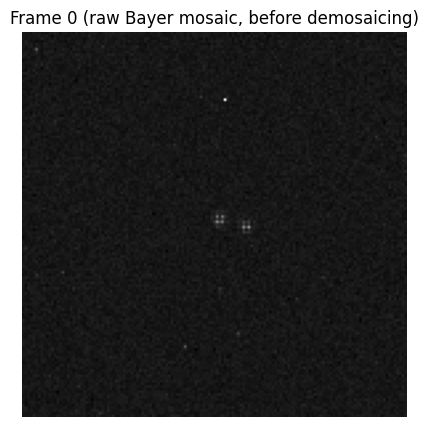

In [4]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(bayer_stack[0], cmap="gray")
ax.set_title("Frame 0 (raw Bayer mosaic, before demosaicing)")
ax.axis("off")
plt.show()

## Write to disk and fit — the same pipeline every analysis notebook uses

Written to a temporary directory here so running this notebook doesn't leave files behind
in the repo; `claude/generate_test_fixtures.py` does the same write (TIFF + `metadata.txt`
ROI sidecar) but into `test_tiffs/` to build a permanent fixture instead.

In [5]:
out_dir = Path(tempfile.mkdtemp()) / "simulated_acquisition"
out_dir.mkdir(parents=True)
io = IOFunctions.IO_Functions()
io.write_tiff(bayer_stack, out_dir / "sim_MMStack_Default.ome.tif", bit="uint16", pixel_size=pipe.pixel_size)
with open(out_dir / "sim_MMStack_Default_metadata.txt", "w") as f:
    json.dump({"FrameKey-0-0-0": {"ROI": f"0-0-{width}-{height}"}}, f)

fc = FittingConfig(peak_wavelength=avg_wl_nm / 1000.0, pfa=1e-3)
pipe.fit(out_dir, mode="smlm", fitting_config=fc)
locs = pipe.load_localisations(out_dir)
cc = ClusteringConfig(min_cluster_size=2)  # STORM: see 01_getting_started_smlm_fitting.ipynb
sm_db, sf_db = pipe.filter_and_cluster(locs, clustering_config=cc)
print(f"{len(sm_db)} molecules recovered from {len(locs)} raw localisations "
      f"({len(ground_truth)} candidates injected)")

INFO:pyS3M.AnalysisPipeline:Starting smlm fit on /tmp/tmpu5feeddy/simulated_acquisition


INFO:pyS3M.SR_Functions:Processing file 1/1: 200 frames in chunks of 1000


INFO:pyS3M.SR_Functions:  Processing chunk: frames 0-199


Detecting puncta:   0%|          | 0/200 [00:00<?, ?it/s]

INFO:pyS3M.SR_Functions:  Found 330 puncta across all chunks


INFO:pyS3M.AnalysisPipeline:smlm fit complete


INFO:pyS3M.AnalysisPipeline:Loaded 209 localisations from 1 file(s) in /tmp/tmpu5feeddy/simulated_acquisition


INFO:pyS3M.AnalysisPipeline:Clustering with HDBSCAN (min_cluster_size=2)


INFO:pyS3M.clustering.hdbscan_clusterer:Using fast_hdbscan for HDBSCAN clustering


14 molecules recovered from 209 raw localisations (38 candidates injected)


## Recovered positions vs. injected ground truth

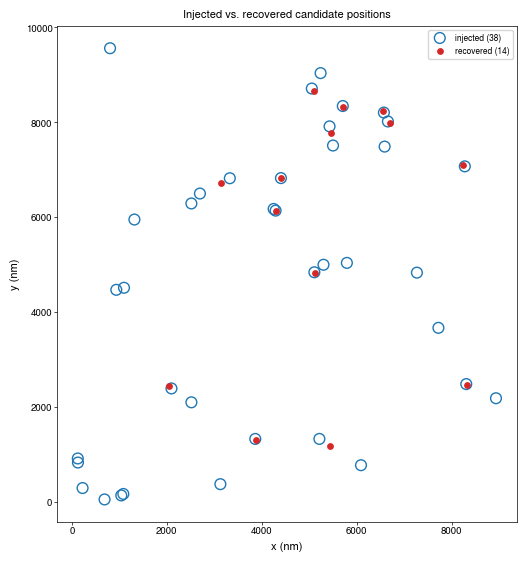

In [6]:
pixel_size_nm = pipe.pixel_size * 1000.0
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(ground_truth["xc_nm"], ground_truth["yc_nm"], s=60, facecolors="none",
           edgecolors="tab:blue", label=f"injected ({len(ground_truth)})")
ax.scatter(sm_db["xc"] * pixel_size_nm, sm_db["yc"] * pixel_size_nm, s=15, color="tab:red",
           label=f"recovered ({len(sm_db)})")
ax.set_aspect("equal")
ax.set_xlabel("x (nm)")
ax.set_ylabel("y (nm)")
ax.set_title("Injected vs. recovered candidate positions")
ax.legend()
plt.show()

## Next: `02_exemplar_psf_and_bayer_grid.ipynb`